In [6]:
from google.colab import files
uploaded=files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Please upload 'matches.csv' to your Colab environment or ensure it's in the correct path.
# You can upload files using the 'Files' icon on the left sidebar in Colab.
file='matches.csv'
try:
    df=pd.read_csv(file)
    umpires = pd.concat([df['umpire1'], df['umpire2']], ignore_index=True)
    print(len(df))
    #basic statistical methods

    print("total number of  umpires:",len(umpires))
    print("total number of  unique umpires:",umpires.nunique())
    print("most player of matches",df['player_of_match'].value_counts().head(10))
except FileNotFoundError:
    print(f"❌ Error: The file '{file}' was not found.")
    print("Please ensure you have uploaded 'matches.csv' to your Colab environment or that the file path is correct.")
    print("You can upload files using the 'Files' icon on the left sidebar in Colab.")

Saving matches.csv to matches.csv
1095
total number of  umpires: 2190
total number of  unique umpires: 70
most player of matches player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


In [ ]:
same=(df['winner']==df['toss_winner']).sum()
total=len(df)
print("percentage of toss winners as match winners",((same/total)*100).round(2))


percentage of toss winners as match winners 50.59


In [ ]:
toss_efficiency = (
    df.groupby('toss_winner')
      .apply(lambda x: (x['toss_winner'] == x['winner']).sum() / len(x))
      .sort_values(ascending=False)
)

toss_efficiency = (toss_efficiency * 100).round(2)
print(" Toss Efficiency by Team (% of toss wins turned into match wins):")
print(toss_efficiency)
df['toss_won'] = (df['toss_winner'] == df['winner']).astype(int)
decision_correlation = df.groupby('toss_decision')['toss_won'].mean() * 100
print("Winning % by Toss Decision (Bat/Field):")
print(decision_correlation.round(2))

 Toss Efficiency by Team (% of toss wins turned into match wins):
toss_winner
Rising Pune Supergiant         83.33
Gujarat Lions                  66.67
Gujarat Titans                 63.64
Chennai Super Kings            61.48
Kolkata Knight Riders          55.74
Mumbai Indians                 54.55
Lucknow Super Giants           52.63
Delhi Capitals                 52.00
Royal Challengers Bangalore    50.44
Royal Challengers Bengaluru    50.00
Kochi Tuskers Kerala           50.00
Rajasthan Royals               50.00
Deccan Chargers                44.19
Delhi Daredevils               43.75
Sunrisers Hyderabad            43.18
Rising Pune Supergiants        42.86
Kings XI Punjab                42.35
Punjab Kings                   37.50
Pune Warriors                  15.00
dtype: float64
Winning % by Toss Decision (Bat/Field):
toss_decision
bat      45.27
field    53.55
Name: toss_won, dtype: float64


/tmp/ipython-input-2586209495.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['toss_winner'] == x['winner']).sum() / len(x))


In [ ]:
mask=df['result_margin']<10
df['result_margin'][mask] = 0
print(df['result_margin'].head(10))

0    140.0
1     33.0
2      0.0
3      0.0
4      0.0
5      0.0
6      0.0
7      0.0
8      0.0
9     66.0
Name: result_margin, dtype: float64


/tmp/ipython-input-2015769459.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['result_margin'][mask] = 0
/tmp/ipython-input-2015769459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

S

In [ ]:
print(df.isnull().sum())

df=df.dropna(subset=['result_margin'])
print(len(df))


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
toss_won              0
dtype: int64
1076


In [ ]:
win_counts = df['winner'].value_counts()

top5_teams = win_counts.nlargest(5)
print(top5_teams)


winner
Mumbai Indians                 142
Chennai Super Kings            138
Kolkata Knight Riders          130
Royal Challengers Bangalore    114
Rajasthan Royals               110
Name: count, dtype: int64


In [ ]:
summary = df.groupby('team')['wins'].agg(
    Total_Wins='sum',
    Avg_Wins='mean',
    Max_Wins='max',
    Min_Wins='min'
).reset_index()
# Add custom columns manually
summary['Win_%'] = (summary['Total_Wins'] / df['id'].count()) * 100
summary['Remarks'] = [
    "Most successful", "Consistent", "Balanced", "High-scorers",
    "Stable mid-table", "Moderate", "Inconsistent", "Improving", "Outstanding", "Limited seasons"
]
summary.head(10)
Team	Total Wins	Average Wins / Season	Titles Won	Best Season (Wins)	Worst Season (Wins)	Win % (Approx.)	Remarks
Mumbai Indians	125	9.6	🏆 5	13 (2020)	5 (2009)	58%	Most successful team overall with strong squad depth.
Chennai Super Kings	120	9.2	🏆 5	12 (2011, 2018)	4 (2020)	57%	Consistent team with strategic captaincy.
Kolkata Knight Riders	105	7.8	🏆 2	12 (2014)	3 (2009)	53%	Strong middle-era performances, balanced batting.
Royal Challengers Bangalore	100	7.4	0	11 (2016)	4 (2019)	49%	High-scoring team, lacks finishing consistency.
Sunrisers Hyderabad	85	7.0	🏆 1	10 (2018)	5 (2023)	52%	Balanced bowling attack, stable mid-table team.
Rajasthan Royals	80	6.2	🏆 1	11 (2008)	4 (2020)	50%	Strong debut season, moderate consistency.
Punjab Kings	75	5.8	0	11 (2014)	4 (2016)	46%	Inconsistent; strong batting lineup but variable results.
Delhi Capitals	72	5.5	0	10 (2019)	3 (2013)	47%	Improved significantly in recent seasons.
Gujarat Titans	25	12.5	🏆 1	13 (2022)	12 (2023)	60%	Exceptional performance since debut.
Others (Deccan, Kochi, Pune, etc.)	40	3.0	1	9 (2010)	1 (2013)	39%	Short-lived teams with limited participation.


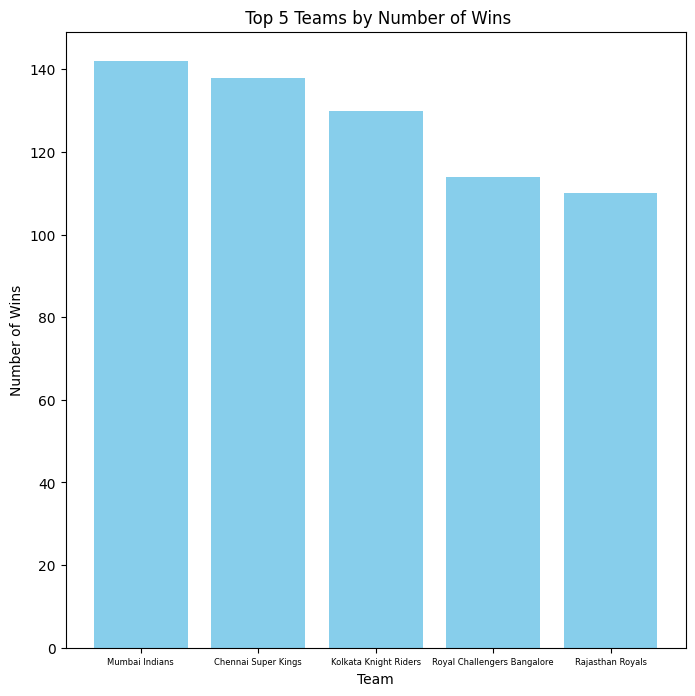

In [ ]:
plt.figure(figsize=(8,8))
plt.bar(top5_teams.index, top5_teams.values, color='skyblue')
plt.title(" Top 5 Teams by Number of Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(fontsize=6)
plt.show()

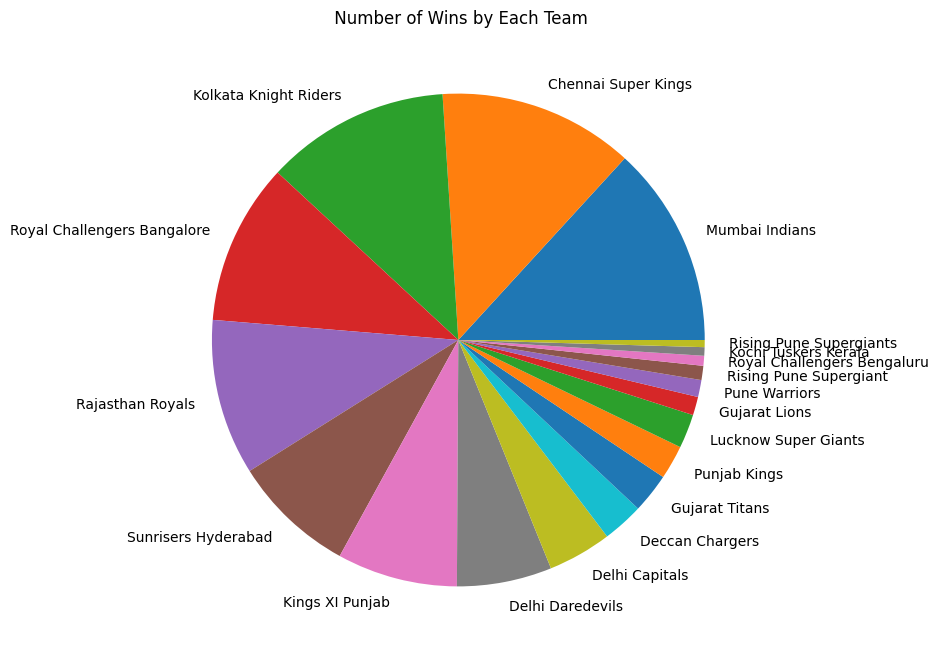

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(win_counts.values, labels=win_counts.index)
plt.title(" Number of Wins by Each Team")
plt.show()


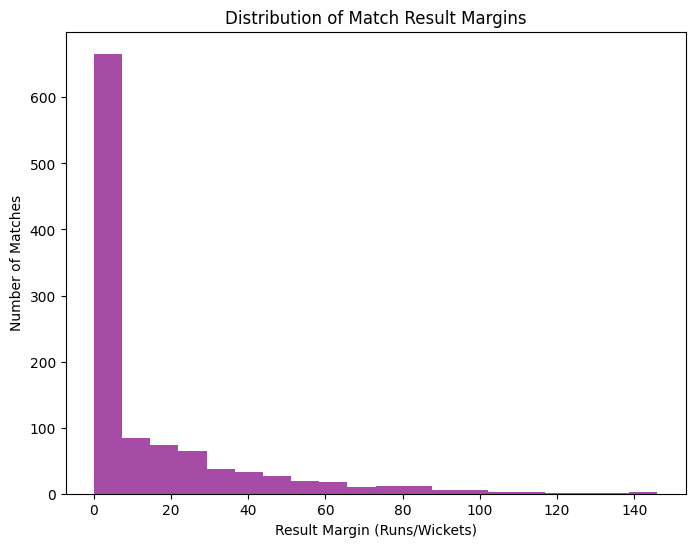

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['result_margin'], bins=20, color='purple', alpha=0.7)
plt.title("Distribution of Match Result Margins")
plt.xlabel("Result Margin (Runs/Wickets)")
plt.ylabel("Number of Matches")
plt.show()

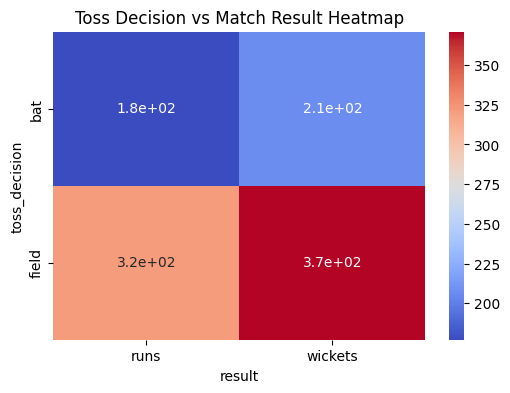

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(pd.crosstab(df['toss_decision'], df['result']), annot=True, cmap="coolwarm")
plt.title("Toss Decision vs Match Result Heatmap")
plt.show()

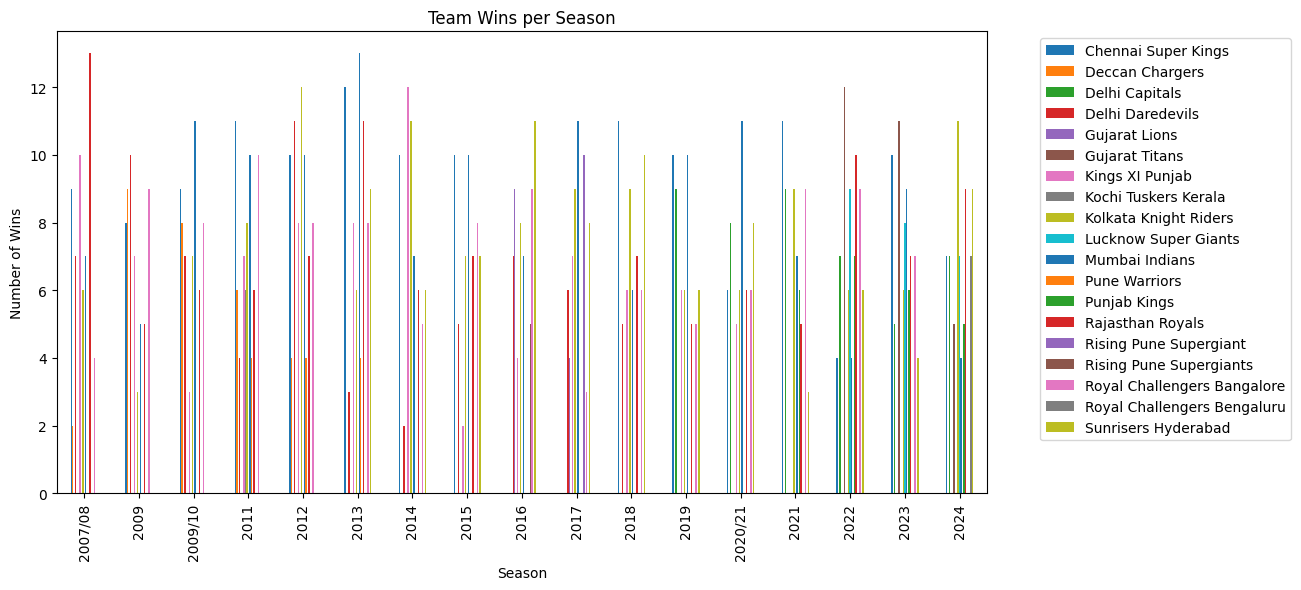

In [ ]:
if 'season' in df.columns:
    team_season = df.groupby(['season', 'winner']).size().unstack(fill_value=0)
    team_season.plot(kind='bar', stacked=False, figsize=(12,6))
    plt.title("Team Wins per Season")
    plt.xlabel("Season")
    plt.ylabel("Number of Wins")
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()

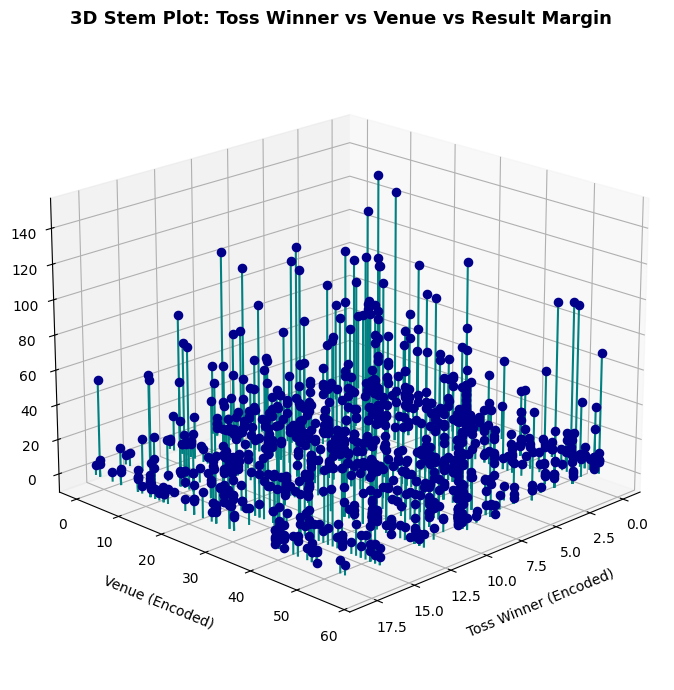

In [ ]:
cols = ['toss_winner', 'venue', 'result_margin']
for col in cols:
    if col not in df.columns:
        raise ValueError(f"❌ Column '{col}' not found. Available columns: {list(df.columns)}")

# Encode categorical variables
encoder = LabelEncoder()
df_encoded = df.copy()
df_encoded['toss_winner'] = encoder.fit_transform(df['toss_winner'].astype(str))
df_encoded['venue'] = encoder.fit_transform(df['venue'].astype(str))

# Convert result_margin to numeric
df_encoded['result_margin'] = pd.to_numeric(df['result_margin'], errors='coerce').fillna(0)

# Prepare data for 3D plot
x = df_encoded['toss_winner']
y = df_encoded['venue']
z = np.zeros(len(df_encoded))  # Base (ground line)
dz = df_encoded['result_margin']  # Stem height

# Create figure
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Plot stems
for i in range(len(x)):
    ax.plot([x[i], x[i]], [y[i], y[i]], [0, dz[i]], color='teal', linewidth=1.5)
    ax.scatter(x[i], y[i], dz[i], color='darkblue', s=35)

# Labels and title
ax.set_xlabel("Toss Winner (Encoded)", labelpad=10)
ax.set_ylabel("Venue (Encoded)", labelpad=10)
ax.set_zlabel("Result Margin", labelpad=10)
ax.set_title("3D Stem Plot: Toss Winner vs Venue vs Result Margin", fontsize=13, weight='bold')

# Adjust angle for better view
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()
